# Committor Analysis Tutorial

As with the TPS analysis tutorial, this is based on results that have already been calculated. This was a simulation of 1000 points selected from a TPS simulation, with 10 committor shots performed on each one -- so a total of 10000 MD simulations.

The committor is closely related to the reaction coordinate: One way to estimate the reaction coordinate is to follow the increasing isocommittors (surfaces with the same value of the committor). The isocommittor with value of 0.5 is particularly interesting: the corresponds to the transition state, where a trajectory started with random velocities has equal probability of ending in reactants or products.

In practice, a full committor analysis is usually very difficult. This one is only partly converged, even with the many, many individual MD simulations included. To reduce the file size, we only saved the first and last snapshot from each committor shot. You can get the file from: https://figshare.com/s/01302bc7a39ec7648ea1

Most of this tutorial is focused on how to use [`OpenPathSampling`](http://openpathsampling.org), however, a couple other libraries play an important role:

* [`matplotlib`](http://matplotlib.org/), a library for creating plots
* [`pandas`](http://pandas.pydata.org/), a library for data analysis
* [`nglview`](https://github.com/arose/nglview), which we'll again use to visualize the molecules

In [1]:
from __future__ import print_function
%matplotlib inline
import openpathsampling as paths
import matplotlib
matplotlib.rcParams.update({'font.size': 18})
matplotlib.rcParams.update({'figure.figsize': (8.8, 6.6)})
import matplotlib.pyplot as plt

import pandas as pd
pd.options.display.max_rows = 10

import nglview as nv

/oden/tnguyen/.local/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


/workspace/tnguyen/miniconda3/envs/OPS/lib/python3.9/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


First we open the file, and load the states and CVs.

In [2]:
%%time
simulation_storage = paths.AnalysisStorage("committor_small.nc")
C_7eq = simulation_storage.volumes['C_7eq']
alpha_R = simulation_storage.volumes['alpha_R']
phi = simulation_storage.cvs['phi']
psi = simulation_storage.cvs['psi']

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



CPU times: user 17.9 s, sys: 551 ms, total: 18.5 s
Wall time: 18.7 s


In [3]:
print("File size: {0} for {1} steps, {2} snapshots".format(
    simulation_storage.file_size_str,
    len(simulation_storage.steps),
    len(simulation_storage.snapshots)
))

File size: 728.34MB for 10000 steps, 42000 snapshots


The initial point for a committor analysis is seen by OPS as a shooting point, so the object to analyze it is `ShootingPointAnalysis`. This is, again, a very time-consuming process (you're analyzing the results of 10000 MD simulations!) It takes ~20 minutes.

In [4]:
analyzer = paths.ShootingPointAnalysis(steps=simulation_storage.steps,
                                       states=[C_7eq, alpha_R])

  0%|          | 0/10000 [00:00<?, ?it/s]

`pandas` is a convenient and widely-used library for a lot of spreadsheet-like data analysis. In addition, it provides a very nice way to present results in Jupyter notebooks, so OpenPathSampling provides the option to return the committor results as a `pandas.DataFrame` object. The first column shows the index number of the initial shooting snapshot, and the other columns show how many landed in each state (where `NaN`, "not-a-number", indicates that 0 shots landed there).

In [5]:
analyzer.to_pandas()

,alpha_R,C_7eq
0,10.0,NaN
1,1.0,9.0
2,NaN,10.0
3,2.0,8.0
4,3.0,7.0
...,...,...
995,1.0,9.0
996,8.0,2.0
997,6.0,4.0
998,2.0,8.0


By using a `label_function`, we can convert the index number of the snapshot to a collective variable that is representative of that snapshot. In this particular case, we'll use $\phi$.

In [6]:
%%time
phi_hash = lambda x : float(phi(x))
analyzer.to_pandas(label_function=phi_hash)

CPU times: user 6.17 s, sys: 14 ms, total: 6.18 s
Wall time: 6.18 s


,alpha_R,C_7eq
-2.563533,10.0,NaN
-2.658631,1.0,9.0
-2.808804,NaN,10.0
-1.865991,2.0,8.0
-2.596682,3.0,7.0
...,...,...
-2.642196,1.0,9.0
-1.824331,8.0,2.0
-2.378637,6.0,4.0
-2.455939,2.0,8.0


Now let's histogram the committor analysis according to the value of `phi`. This requires using the `phi_hash`, and will give a one-dimensional histogram.

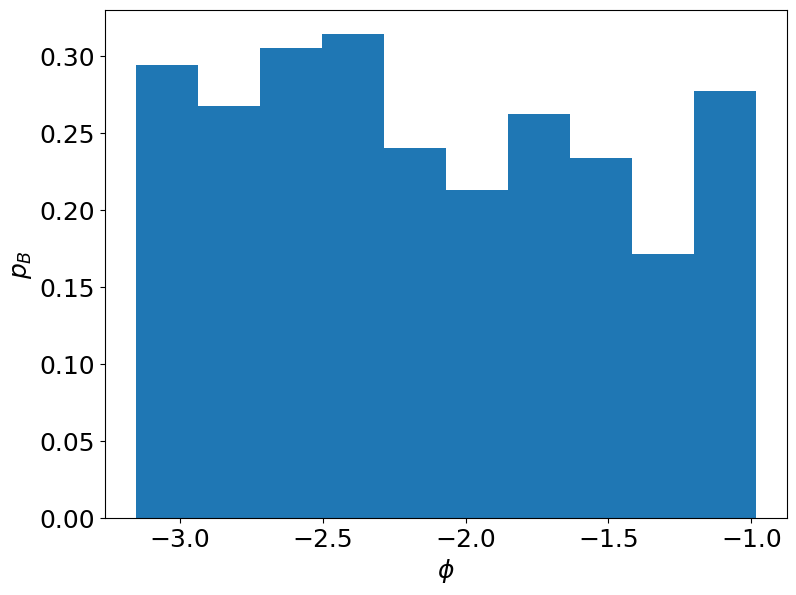

In [7]:
hist1D, phi_bins = analyzer.committor_histogram(phi_hash, alpha_R, bins=10)
bin_widths = [phi_bins[i+1]-phi_bins[i] for i in range(len(phi_bins)-1)]
plt.bar(x=phi_bins[:-1], height=hist1D, width=bin_widths)
plt.xlabel("$\phi$")
plt.ylabel("$p_B$");

* Is $\phi$ a good representation of the reaction coordinate? No since moving along $\phi$ dimension, the rate does not change much.

Now you'll do exactly the same for the other main CV we use in this: $\psi$. Follow the procedure used above to make a one-dimensional histogram according to a specific CV.

In [8]:
# YOUR TURN: Do the same for the psi variable.
# Remember to start by creating a `psi_hash`.
psi_hash = lambda x : float(psi(x))
analyzer.to_pandas(label_function=psi_hash)

,alpha_R,C_7eq
0.098042,10.0,NaN
1.319730,1.0,9.0
1.736534,NaN,10.0
0.848403,2.0,8.0
0.627350,3.0,7.0
...,...,...
1.142649,1.0,9.0
0.376055,8.0,2.0
0.621228,6.0,4.0
0.953096,2.0,8.0


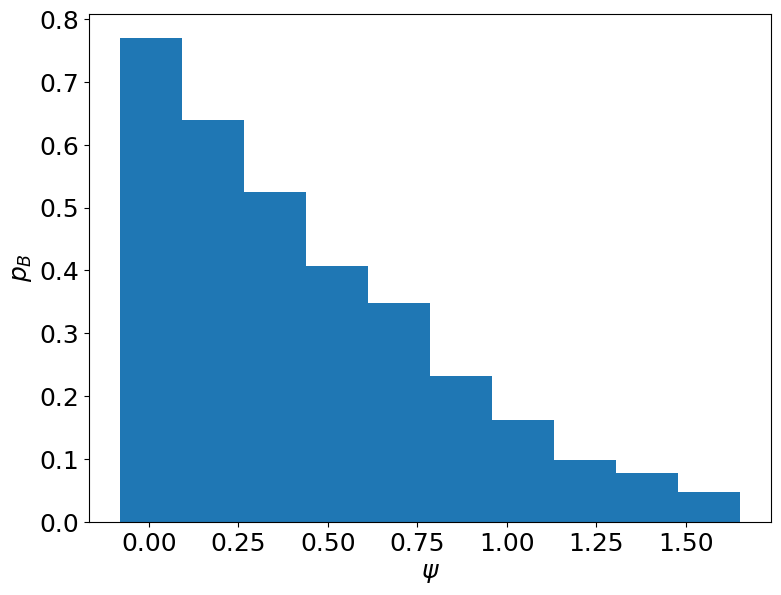

In [10]:
hist1D, psi_bins = analyzer.committor_histogram(psi_hash, alpha_R, bins=10)
bin_widths = [psi_bins[i+1]-psi_bins[i] for i in range(len(psi_bins)-1)]
plt.bar(x=psi_bins[:-1], height=hist1D, width=bin_widths)
plt.xlabel("$\psi$")
plt.ylabel("$p_B$");

* Compare this with the $\phi$ histogram. Which is a better representation of the reaction coordinate: $\phi$ or $\psi$? $\psi$

Is the one-dimensional histogram enough information? Here we'll make a two-dimensional histogram including both $\phi$ and $\psi$. The color will tell us the value of the committor.

In [11]:
%%time
ramachandran_hash = lambda x : (float(phi(x)), float(psi(x)))
hist2D, bins_phi, bins_psi = analyzer.committor_histogram(ramachandran_hash, alpha_R, bins=20)

CPU times: user 17.5 ms, sys: 996 µs, total: 18.5 ms
Wall time: 17.3 ms


/tmp/ipykernel_1138724/3253433874.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar();


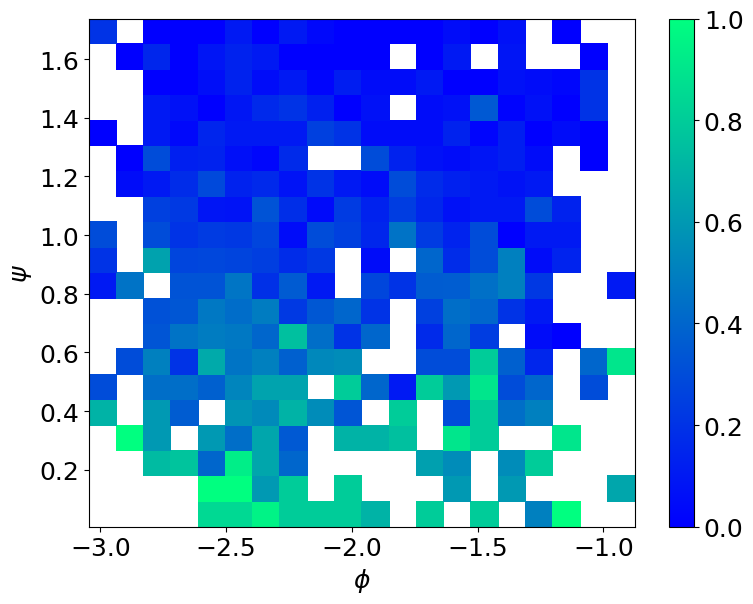

In [12]:
plt.pcolor(bins_phi, bins_psi, hist2D.T, cmap="winter")
plt.clim(0.0, 1.0)
plt.xlabel("$\phi$")
plt.ylabel("$\psi$")
plt.colorbar();

Since the most interesting part of the committor is the 0.5 isocommittor, we'll focus on that.

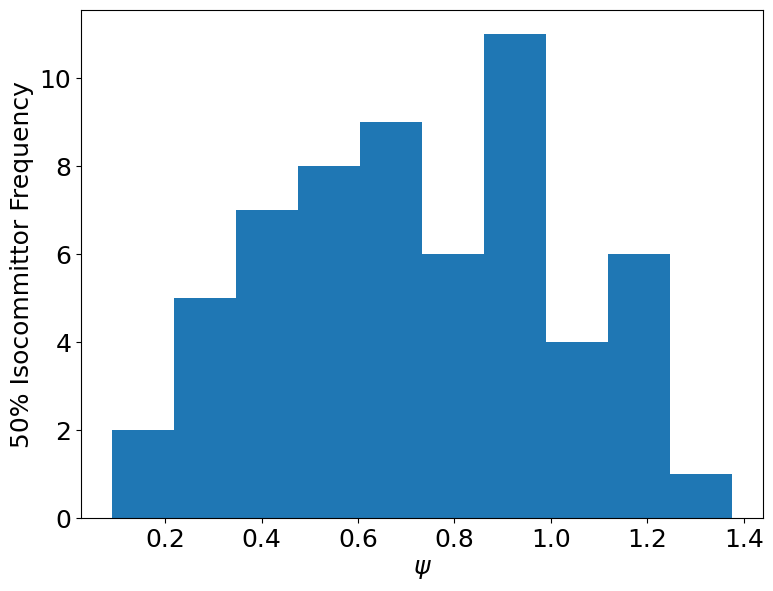

In [13]:
# identify the committor 0.5 frames; histogram them by psi
# we use a powerful Python trick called a "list comprehension" to make `isocommittor_0x5`
# list comprehensions are a bit hard to understand at first, but very useful once you're used to them
committor = analyzer.committor(alpha_R)
isocommittor_0x5 = [s for s in committor if 0.45 < committor[s] < 0.55]

plt.hist(psi(isocommittor_0x5))
plt.xlabel("$\psi$")
plt.ylabel("50% Isocommittor Frequency");

You'll notice that this is *not* very sharply peaked in $\psi$. This means that $\psi$ alone probably doesn't define the transition state.

If $\psi$ did define the transition state, we'd probably expect the transition state to be around $\psi = 0.6$ (\~35 degrees) to $\psi = 1.0$ (\~60 degrees). Now, instead of keeping the committor probability fixed and histogramming the values of $\psi$, let's see what the values of the committor are for a fixed value of $\psi = \psi^*$. If $\psi^*$ defined the transition state, then the committor would always be 0.5 here.

Previous, we tried to show that frames with a committor around 0.5 had a certain value of $\psi$. Now we're trying to see if that value of $\psi$ always implies that frames have a committor around 0.5. We need to show both directions before we can claim that the transition state is defined by that value of $\psi$.

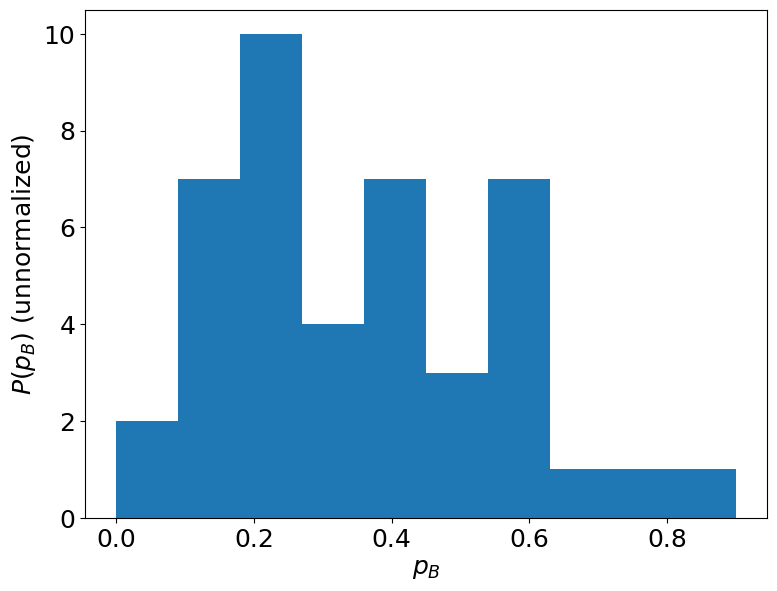

In [17]:
# take a range around a central psi_star value
psi_star_min = 0.8
psi_star_max = 0.85

psi_star_snapshots = [s for s in committor 
                      if psi_star_min <= psi(s) <= psi_star_max]
plt.hist([committor[s] for s in psi_star_snapshots]);
plt.xlabel("$p_B$")
plt.ylabel("$P(p_B)$ (unnormalized)");

Try a few different values of `psi_star_min` and `psi_star_max`. 

* Do you ever get a distribution that is peaked around $p_B = 0.5$?

Now you should select a few frames from the 50% isocommittor surface (i.e., the transition state ensemble) and visualize them using `nglview`. The variable `isocommittor_0x5` contains a list of the appropriate snapshots, so you can pick whichever ones you want. Let's see how many such frames we found:

In [18]:
len(isocommittor_0x5)

59

Repeat the following several times, changing the number `2` in `isocommittor_0x5[2]` to other choices, and compare the conformations you see. (Don't expect to be able to identify the "hidden" variable: The conclusion from [Bolhuis et al.](http://dx.doi.org/10.1073/pnas.100127697) was that the water itself plays an important role in this reaction, and even they couldn't identify exactly what the water-related reaction coordinate should be!)

In [20]:
# YOUR TURN: modify the snapshot number; compare the conformations
md_traj_A = paths.Trajectory([isocommittor_0x5[3]]).to_mdtraj().image_molecules()
view_A = nv.show_mdtraj(md_traj_A)
view_A.clear()
view_A.add_ball_and_stick("ACE ALA NME")
view_A.center()
view_A

NGLWidget()